# Assignment 2 — A Day in San Francisco's Crime

A short data story exploring how the city's crime profile transforms hour by hour.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Load the unified SF crime dataset (2003–2025), built in Assignment 1
df = pd.read_parquet('../Assignment1_marcus/sf_crime_2003_2025.parquet')
df['hour'] = df['Incident Datetime'].dt.hour
print(f"Dataset: {len(df):,} incidents (2003–2025)")

Dataset: 2,934,658 incidents (2003–2025)


## Visualization 1: The Crime Clock

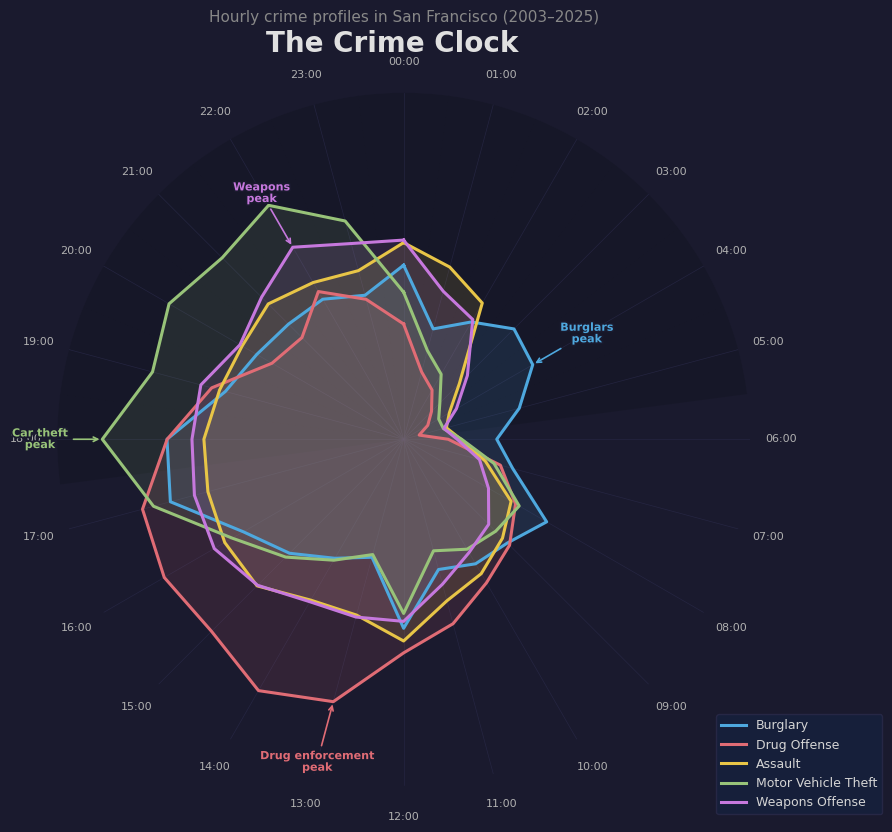

In [18]:
# ── Final 5 focus crimes — consistent across all visualizations ──
crimes = {
    'Burglary':           {'color': '#4ea8de'},
    'Drug Offense':       {'color': '#e06c75'},
    'Assault':            {'color': '#e8c547'},
    'Motor Vehicle Theft':{'color': '#98c379'},
    'Weapons Offense':    {'color': '#c678dd'},
}

# ── Normalized hourly distributions (shape of the day, not raw volume) ──
hours = np.arange(24)
profiles = {}
for crime in crimes:
    counts = (df[df['Incident Category'] == crime]
              .groupby('hour').size()
              .reindex(hours, fill_value=0).values.astype(float))
    profiles[crime] = counts / counts.sum()

# ── Polar plot ──
angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)
angles_plot = np.concatenate([angles, [angles[0]]])

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

for crime, style in crimes.items():
    vals = np.concatenate([profiles[crime], [profiles[crime][0]]])
    ax.plot(angles_plot, vals, color=style['color'], linewidth=2.2, label=crime, zorder=3)
    ax.fill(angles_plot, vals, color=style['color'], alpha=0.12, zorder=2)

r_max = max(p.max() for p in profiles.values()) * 1.15
ax.set_ylim(0, r_max)

ax.set_xticks(angles)
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], fontsize=8, color='#b0b0b0')
ax.set_rticks([])
ax.spines['polar'].set_visible(False)
ax.grid(True, color='#2a2a4a', linewidth=0.5, alpha=0.7)
ax.tick_params(axis='x', pad=12)

# Night shading
for h in list(range(18, 24)) + list(range(0, 6)):
    ax.bar(h * 2 * np.pi / 24, r_max, width=2 * np.pi / 24, bottom=0,
           color='#0d1117', alpha=0.25, zorder=0, edgecolor='none')

# Peak annotations
for hour, crime, text, color in [
    (4,  'Burglary',            'Burglars\npeak',             '#4ea8de'),
    (13, 'Drug Offense',        'Drug enforcement\npeak',     '#e06c75'),
    (18, 'Motor Vehicle Theft', 'Car theft\npeak',            '#98c379'),
    (22, 'Weapons Offense',     'Weapons\npeak',              '#c678dd'),
]:
    a = hour * 2 * np.pi / 24
    ax.annotate(text, xy=(a, profiles[crime][hour]),
                xytext=(a, profiles[crime][hour] + r_max * 0.18),
                fontsize=8, fontweight='bold', color=color, ha='center', va='center',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
                path_effects=[pe.withStroke(linewidth=2.5, foreground='#1a1a2e')])

ax.legend(loc='lower right', bbox_to_anchor=(1.2, -0.05), fontsize=9,
          frameon=True, fancybox=True,
          facecolor='#16213e', edgecolor='#2a2a4a', labelcolor='#d4d4d4')
fig.suptitle('The Crime Clock', fontsize=20, fontweight='bold', color='#e0e0e0', y=0.95)
ax.set_title('Hourly crime profiles in San Francisco (2003–2025)',
             fontsize=11, color='#888888', pad=25)

plt.savefig('crime_clock.png', dpi=200, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## Visualization 2: Crime Geography by District

In [19]:
import plotly.express as px
import json

# ── Same 5 focus crimes as Viz 1 ──
focus_crimes = ['Burglary', 'Drug Offense', 'Assault', 'Motor Vehicle Theft', 'Weapons Offense']

df_valid = df[
    df['Police District'].notna() &
    (df['Police District'] != 'Out Of Sf') &
    (df['Incident Category'].isin(focus_crimes))
].copy()
df_valid['is_business'] = df_valid['hour'].between(9, 16)

biz = (df_valid.groupby('Police District')['is_business']
       .agg(['sum', 'count'])
       .rename(columns={'sum': 'business', 'count': 'total'}))
biz['biz_fraction'] = biz['business'] / biz['total'] * 100
biz = biz.reset_index()
biz.columns = ['district', 'business', 'total', 'biz_fraction']

print(biz[['district', 'biz_fraction']].sort_values('biz_fraction', ascending=False).to_string(index=False))

# ── Load GeoJSON ──
with open('../Assignment1_marcus/Current_Police_Districts_20260224.geojson') as f:
    geojson = json.load(f)

for feature in geojson['features']:
    feature['properties']['district'] = feature['properties']['district'].title()

# ── Plotly choropleth ──
fig = px.choropleth_map(
    biz,
    geojson=geojson,
    locations='district',
    featureidkey='properties.district',
    color='biz_fraction',
    color_continuous_scale='RdYlGn',
    range_color=[biz['biz_fraction'].min() - 1, biz['biz_fraction'].max() + 1],
    map_style='carto-darkmatter',
    zoom=11,
    center={'lat': 37.773, 'lon': -122.437},
    opacity=0.8,
    hover_data={'district': True, 'biz_fraction': ':.1f', 'total': ':,'},
    labels={'biz_fraction': '% during business hours', 'total': 'Total incidents'},
)

fig.update_layout(
    title=dict(
        text='Day vs Night Crime by District<br>'
             '<sup>Percentage of focus crime incidents occurring between 09:00–17:00 (2003–2025)</sup>',
        font=dict(size=16, color='#e0e0e0'),
        x=0.5,
    ),
    paper_bgcolor='#1a1a2e',
    margin=dict(l=0, r=0, t=70, b=0),
    coloraxis_colorbar=dict(
        title='% 09:00–17:00',
        tickfont=dict(color='#b0b0b0'),
        title_font=dict(color='#b0b0b0'),
    ),
)

fig.write_html('crime_peak_hour_map.html', include_plotlyjs='cdn')
fig.show()

  district  biz_fraction
Tenderloin     46.449609
  Southern     39.584590
      Park     38.744645
   Bayview     38.064445
   Taraval     36.503085
   Mission     35.577971
  Richmond     34.999856
  Northern     34.498219
 Ingleside     34.432199
   Central     33.443602


## Visualization 3: Crime Through the Day — Interactive Hour Map

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ── Same 5 focus crimes as Viz 1 & 2 ──
focus_crimes = ['Burglary', 'Drug Offense', 'Assault', 'Motor Vehicle Theft', 'Weapons Offense']
crime_colors = {
    'Burglary':            '#4ea8de',
    'Drug Offense':        '#e06c75',
    'Assault':             '#e8c547',
    'Motor Vehicle Theft': '#98c379',
    'Weapons Offense':     '#c678dd',
}

# ── Filter to SF bounds and focus crimes ──
df_focus = df[
    df['Incident Category'].isin(focus_crimes) &
    df['Latitude'].between(37.70, 37.83) &
    df['Longitude'].between(-122.53, -122.35)
].dropna(subset=['Latitude', 'Longitude']).copy()

df_focus['year'] = df_focus['Incident Datetime'].dt.year

# ── Normalized hourly profile (same as Viz 1) ──
hours = np.arange(24)
profiles = {}
for crime in focus_crimes:
    counts = (df_focus[df_focus['Incident Category'] == crime]
              .groupby('hour').size()
              .reindex(hours, fill_value=0).values.astype(float))
    profiles[crime] = counts / counts.max()

# ── Proportional sampling ──
MAX_N = 600
rng = np.random.default_rng(42)

frames_list = []
for crime in focus_crimes:
    grp_crime = df_focus[df_focus['Incident Category'] == crime]
    for h in range(24):
        grp_hour = grp_crime[grp_crime['hour'] == h]
        n = max(1, round(MAX_N * profiles[crime][h]))
        if len(grp_hour) > n:
            grp_hour = grp_hour.iloc[rng.choice(len(grp_hour), n, replace=False)]
        frames_list.append(grp_hour[[
            'Latitude', 'Longitude', 'Incident Category',
            'Incident Description', 'Police District', 'year', 'hour'
        ]])

sampled = pd.concat(frames_list)
sampled['hour_label'] = sampled['hour'].apply(lambda h: f'{h:02d}:00')
sampled = sampled.sort_values('hour')

# Count lookup
count_pivot = (sampled.groupby(['hour_label', 'Incident Category'])
               .size().unstack(fill_value=0))

def get_counts(hour_label):
    return [int(count_pivot.loc[hour_label, c]) if c in count_pivot.columns else 0
            for c in focus_crimes]

hour_labels = [f'{h:02d}:00' for h in range(24)]

# ── Build figure with map + bar subplots ──
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.65, 0.35],
    specs=[[{'type': 'map'}, {'type': 'xy'}]],
    horizontal_spacing=0.04,
)

# Initial state: 00:00
for crime in focus_crimes:
    h0 = sampled[(sampled['Incident Category'] == crime) & (sampled['hour_label'] == '00:00')]
    fig.add_trace(go.Scattermap(
        lat=h0['Latitude'].tolist(),
        lon=h0['Longitude'].tolist(),
        mode='markers',
        marker=dict(size=8, color=crime_colors[crime], opacity=0.75),
        name=crime,
        customdata=h0[['Incident Description', 'Police District', 'year']].values.tolist(),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'District: %{customdata[1]}<br>'
            'Year: %{customdata[2]}'
            '<extra></extra>'
        ),
    ), row=1, col=1)

counts_00 = get_counts('00:00')
fig.add_trace(go.Bar(
    x=counts_00,
    y=list(range(len(focus_crimes))),
    orientation='h',
    marker=dict(color=[crime_colors[c] for c in focus_crimes], opacity=0.85),
    showlegend=False,
    text=counts_00,
    textposition='outside',
    textfont=dict(color='#d4d4d4', size=11),
    hovertemplate='%{x} incidents<extra></extra>',
), row=1, col=2)

# ── Animation frames ──
anim_frames = []
for hl in hour_labels:
    frame_data = []
    for crime in focus_crimes:
        hdf = sampled[(sampled['Incident Category'] == crime) & (sampled['hour_label'] == hl)]
        frame_data.append(go.Scattermap(
            lat=hdf['Latitude'].tolist(),
            lon=hdf['Longitude'].tolist(),
            customdata=hdf[['Incident Description', 'Police District', 'year']].values.tolist(),
        ))
    counts = get_counts(hl)
    frame_data.append(go.Bar(x=counts, text=counts, textposition='outside'))
    anim_frames.append(go.Frame(data=frame_data, name=hl))

fig.frames = anim_frames

# ── Layout ──
fig.update_layout(
    map=dict(
        style='carto-darkmatter',
        center=dict(lat=37.773, lon=-122.437),
        zoom=11,
    ),
    plot_bgcolor='#16213e',
    paper_bgcolor='#1a1a2e',
    title=dict(
        text="A Day in San Francisco's Crime<br>"
             "<sup>Each dot is a real incident — dot count scales with hourly activity</sup>",
        font=dict(size=16, color='#e0e0e0'),
        x=0.5,
    ),
    margin=dict(l=0, r=20, t=70, b=80),
    legend=dict(
        font=dict(color='#d4d4d4', size=11),
        bgcolor='#16213e',
        bordercolor='#2a2a4a',
        borderwidth=1,
        x=0.01, y=0.99,
        xanchor='left', yanchor='top',
    ),
    updatemenus=[dict(
        type='buttons', showactive=True,
        y=-0.1, x=0.02, xanchor='left',
        buttons=[
            dict(label='▶ Play', method='animate',
                 args=[None, dict(frame=dict(duration=400, redraw=True), fromcurrent=True)]),
            dict(label='⏸ Pause', method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]),
        ],
        font=dict(color='#d4d4d4'),
    )],
    sliders=[dict(
        steps=[dict(
            args=[[hl], dict(frame=dict(duration=300, redraw=True), mode='immediate')],
            label=hl, method='animate',
        ) for hl in hour_labels],
        currentvalue=dict(prefix='Hour: ', font=dict(color='#e0e0e0', size=13)),
        font=dict(color='#b0b0b0'),
        x=0.1, len=0.88, y=-0.04,
        bgcolor='#2a2a4a', bordercolor='#3a3a6a',
    )],
)

fig.update_yaxes(
    showticklabels=False,
    ticks='',
    tickvals=[],
    range=[-0.5, len(focus_crimes) - 0.5],
    autorange=False,
    row=1, col=2,
)
fig.update_xaxes(
    range=[0, MAX_N * 1.35],
    showgrid=True, gridcolor='#2a2a4a',
    zeroline=False,
    tickfont=dict(color='#888888'),
    title=dict(text='Incidents in sample', font=dict(color='#888888', size=10)),
    row=1, col=2,
)

fig.write_html('crime_hour_map.html', include_plotlyjs='cdn')
fig.show()